C:\Users\NT371B5A\AppData\Local\Temp\ipykernel_15044\4034519746.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_sample, x='city', y='min_dist', palette=colors, edgecolor='black', linewidth=0.5)


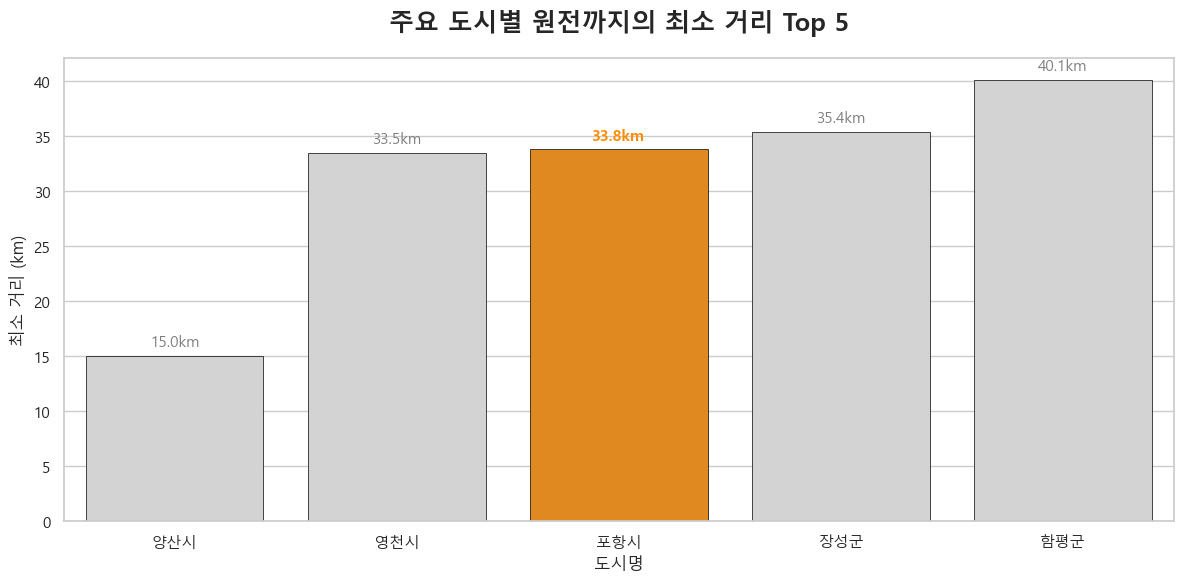

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 및 스타일 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font='Malgun Gothic')

# 2. 파일 읽기
df = pd.read_csv('location_with_distances.csv', encoding='utf-8')

# 3. 상위 5개 지역
df_sample = df.head(5).copy()

# 4. 색상 리스트 생성 ('city'가 '포항시'이면 주황색, 아니면 연한 회색)
colors = ['#FF8C00' if city == '포항시' else '#D3D3D3' for city in df_sample['city']]

# 5. 그래프 그리기
plt.figure(figsize=(12, 6))
# palette에 색상 리스트를 직접 전달합니다.
ax = sns.barplot(data=df_sample, x='city', y='min_dist', palette=colors, edgecolor='black', linewidth=0.5)

# 6. 그래프 꾸미기
plt.title('주요 도시별 원전까지의 최소 거리 Top 5', fontsize=18, pad=20, fontweight='bold')
plt.xlabel('도시명', fontsize=12)
plt.ylabel('최소 거리 (km)', fontsize=12)

# 7. 막대 하나씩 가져오기
for p in ax.patches:
    # 현재 막대의 높이와 도시명 가져오기
    height = p.get_height()

    # 막대에 글씨 쓰기
    ax.annotate(f'{height:.1f}km', 
                (p.get_x() + p.get_width() / 2., height), # 막대 중앙의 위치
                ha='center', va='center', # 가로, 세로 가운데
                xytext=(0, 10), # 막대 위로 10포인트 띄움
                textcoords='offset points',
                fontsize=11,
                fontweight='bold' if height == df_sample.loc[df_sample['city'] == '포항시', 'min_dist'].values[0] else 'normal',
                color='#FF8C00' if height == df_sample.loc[df_sample['city'] == '포항시', 'min_dist'].values[0] else 'gray')

plt.tight_layout()
plt.show()

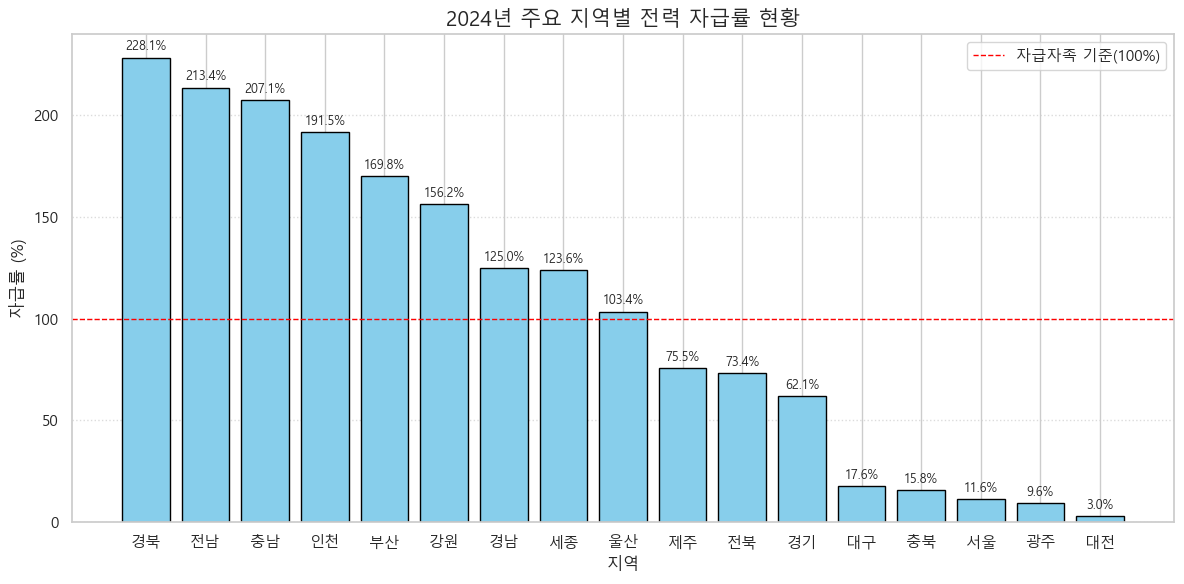

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 로드
df_gen = pd.read_csv('HOME_발전·판매_발전량_지역별.csv', encoding='cp949')
df_sales = pd.read_csv('HOME_발전·판매_판매전력량_시도별용도별.csv', encoding='cp949', header=[0, 1, 2])

# 2. 발전량 데이터 정리
gen_2024 = df_gen[df_gen['연도'] == 2024].drop('연도', axis=1).T
gen_2024.columns = ['발전량']

# 3. 소비량 데이터 정리
sales_2024 = df_sales.iloc[:, [0, -1]] # 지역구분과 최종 합계 컬럼
sales_2024.columns = ['지역', '판매량']
sales_2024 = sales_2024.set_index('지역')

# 4. 데이터 병합 및 자급률 계산
df_analysis = pd.concat([gen_2024, sales_2024], axis=1, join='inner')
df_analysis['자급률'] = (df_analysis['발전량'] / df_analysis['판매량']) * 100
df_analysis = df_analysis.sort_values(by='자급률', ascending=False)

# 5. 시각화
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 6))
bars = plt.bar(df_analysis.index, df_analysis['자급률'], color='skyblue', edgecolor='black')

# 자급률 100% 선 표시
plt.axhline(y=100, color='red', linestyle='--', linewidth=1, label='자급자족 기준(100%)')

# 수치 표시
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval:.1f}%', ha='center', va='bottom', fontsize=9)

plt.title('2024년 주요 지역별 전력 자급률 현황', fontsize=15)
plt.xlabel('지역')
plt.ylabel('자급률 (%)')
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

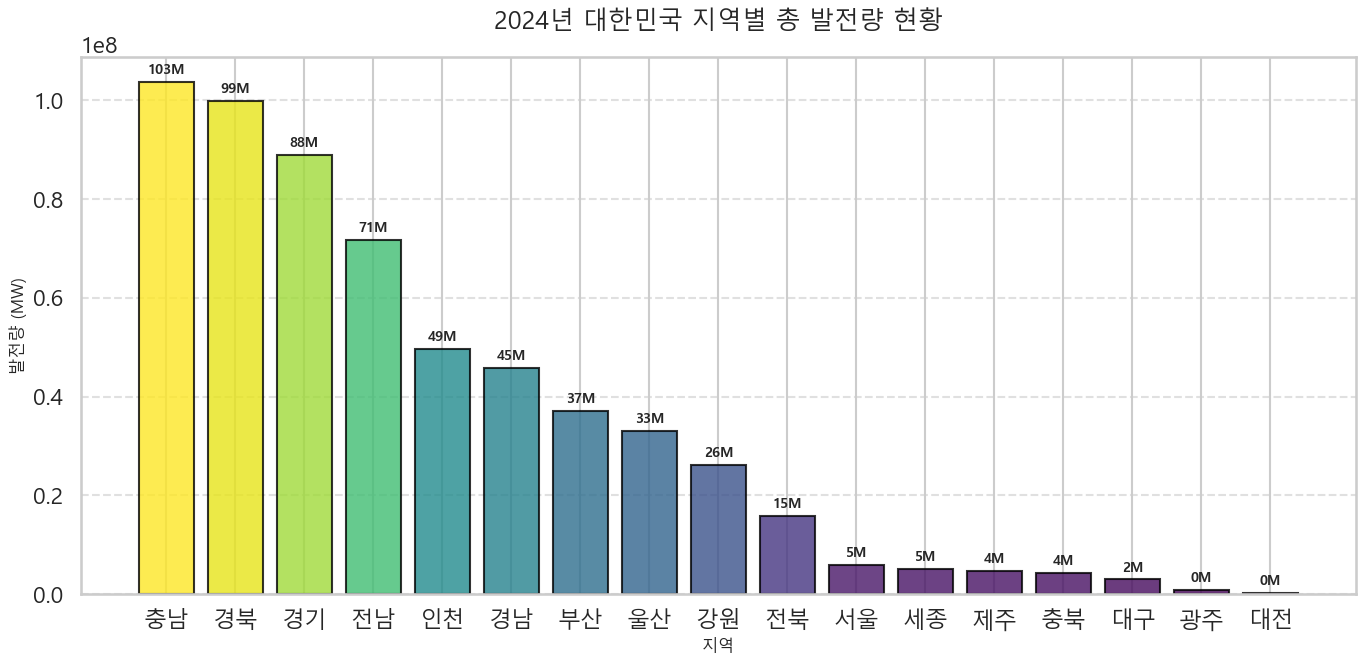

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 로드
df_gen = pd.read_csv('HOME_발전·판매_발전량_지역별.csv', encoding='cp949')

# 2. 2024년 데이터만 추출 및 전처리
df_2024 = df_gen[df_gen['연도'] == 2024].drop('연도', axis=1)

# 그래프를 그리기 위해 데이터 구조 변경
df_plot = df_2024.iloc[0].sort_values(ascending=False)

# 3. 시각화 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(14, 7))
colors = plt.cm.viridis(df_plot.values / max(df_plot.values)) # 발전량에 따른 색상 차이
bars = plt.bar(df_plot.index, df_plot.values, color=colors, edgecolor='black', alpha=0.8)

# 4. 그래프 디테일 추가
plt.title('2024년 대한민국 지역별 총 발전량 현황', fontsize=18, pad=20)
plt.xlabel('지역', fontsize=12)
plt.ylabel('발전량 (MW)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# 막대 위에 수치 표시 (단위: 백만)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1000000,
             f'{int(height/1000000):,}M', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

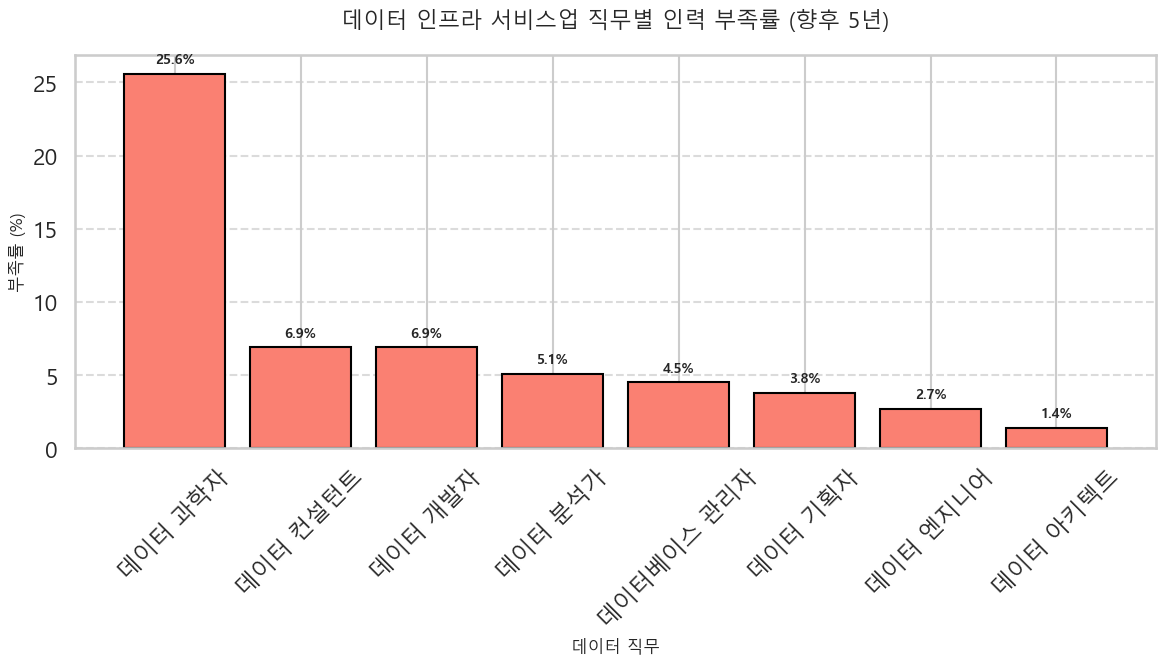

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 로드 (인덱스 컬럼을 직무명으로 설정)
df = pd.read_csv('데이터직무별_인력부족률.csv', index_col=0)

# 2. 데이터 인프라 서비스업 컬럼만 추출 (평균 행 제외)
target_col = [col for col in df.columns if '데이터 인프라' in col][0]
infra_data = df[target_col].drop('평균')

# 3. 시각화 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 7))
# 부족률이 높은 순서대로 정렬하여 시각화
infra_data_sorted = infra_data.sort_values(ascending=False)
bars = plt.bar(infra_data_sorted.index, infra_data_sorted.values, color='salmon', edgecolor='black')

# 4. 그래프 디테일 추가
plt.title('데이터 인프라 서비스업 직무별 인력 부족률 (향후 5년)', fontsize=16, pad=20)
plt.ylabel('부족률 (%)', fontsize=12)
plt.xlabel('데이터 직무', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 막대 위에 % 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

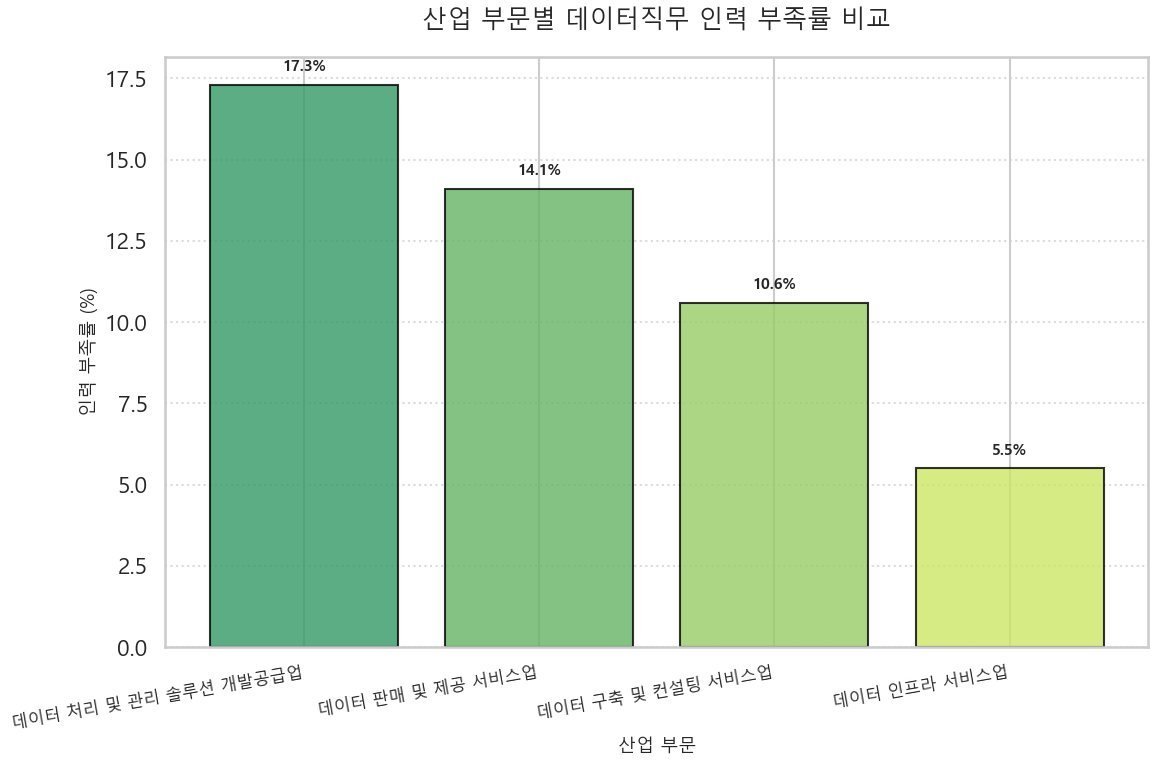

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드
df = pd.read_csv('데이터직무별_인력부족률.csv', index_col=0)

# 2. 평균 행만 추출하여 산업 부문별 비교 데이터 생성
if '데이터산업 전체' in df.columns:
    avg_data = df.loc['평균'].drop('데이터산업 전체')
else:
    avg_data = df.loc['평균']

# 3. 시각화 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(12, 8))

# 데이터 정렬 (부족률이 높은 순서대로)
avg_data_sorted = avg_data.sort_values(ascending=False)

# 막대 그래프 그리기
colors = sns.color_palette('summer', len(avg_data_sorted))
bars = plt.bar(avg_data_sorted.index, avg_data_sorted.values, color=colors, edgecolor='black', alpha=0.8)

# 4. 그래프 디테일 추가
plt.title('산업 부문별 데이터직무 인력 부족률 비교', fontsize=18, pad=20)
plt.ylabel('인력 부족률 (%)', fontsize=13)
plt.xlabel('산업 부문', fontsize=13)
plt.xticks(fontsize=12, rotation=10, ha='right')
plt.grid(axis='y', linestyle=':', alpha=0.7)

# 막대 위에 정확한 수치 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.3,
             f'{height}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

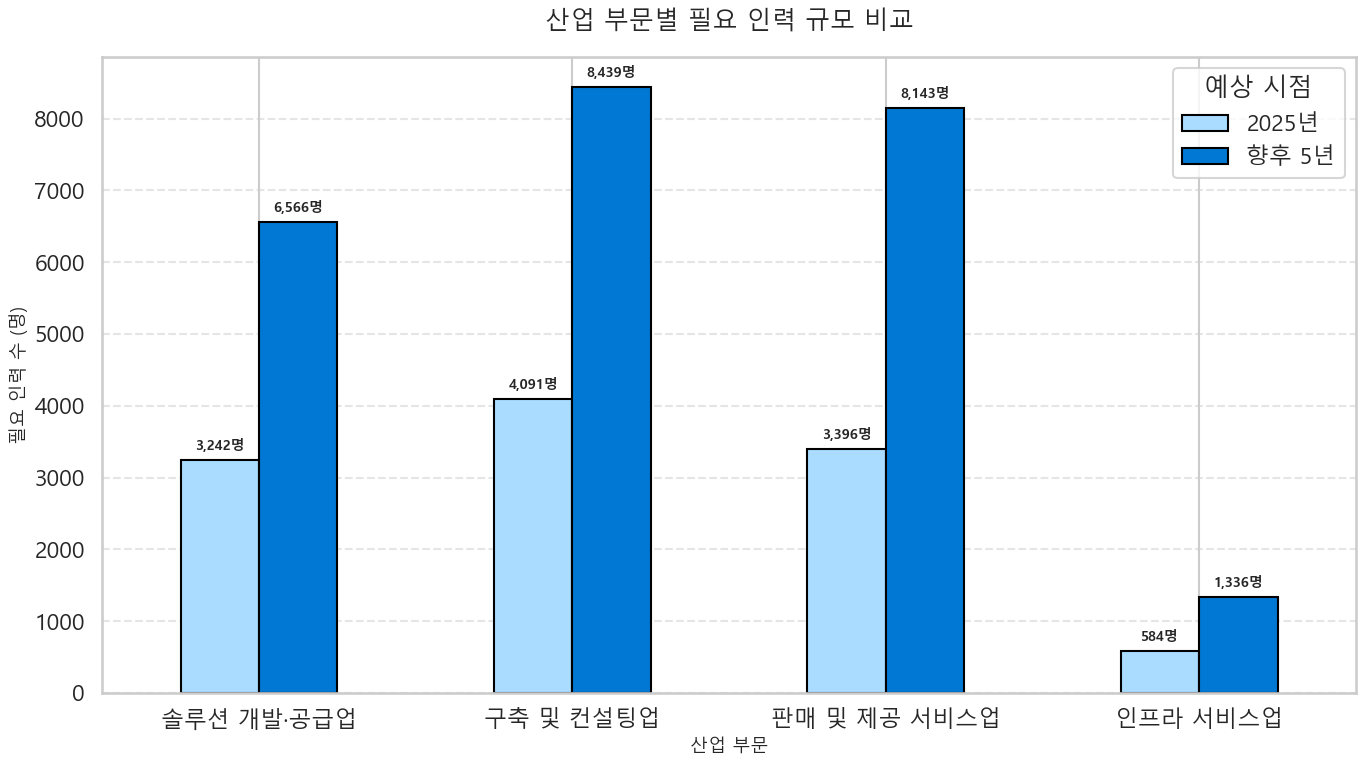

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 로드
df = pd.read_csv('데이터직무별_필요인력.csv')

# 2. 데이터 추출 (수치 데이터는 1번 인덱스 행에 위치함)
sectors = ['솔루션 개발·공급업', '구축 및 컨설팅업', '판매 및 제공 서비스업', '인프라 서비스업']
years = ['2025년', '향후 5년']

data_values = []
# 데이터가 있는 행은 1번(인력수 행)입니다.
# 열(Column)은 1번부터 8번까지 2개씩 짝지어 가져옵니다.
for i in range(1, 9, 2):
    try:
        # 콤마 제거 및 정수 변환 (iloc[1, i]로 수정)
        val_2025 = int(str(df.iloc[1, i]).replace(',', ''))
        val_5years = int(str(df.iloc[1, i+1]).replace(',', ''))
        data_values.append([val_2025, val_5years])
    except (ValueError, TypeError):
        # 변환 실패 시 0으로 처리하거나 에러 방지
        data_values.append([0, 0])

# 시각화를 위한 데이터프레임 생성
df_plot = pd.DataFrame(data_values, index=sectors, columns=years)

# 3. 시각화 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

ax = df_plot.plot(kind='bar', figsize=(14, 8), color=['#AADCFF', '#0078D4'], edgecolor='black', rot=0)

# 4. 그래프 디테일 추가
plt.title('산업 부문별 필요 인력 규모 비교', fontsize=18, pad=20)
plt.ylabel('필요 인력 수 (명)', fontsize=13)
plt.xlabel('산업 부문', fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='예상 시점')

# 막대 위에 수치 표시
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height):,}명', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 10), 
                    textcoords='offset points',
                    fontsize=10,
                    fontweight='bold')

plt.tight_layout()
plt.show()